# Crop Yield Prediction for Maize Farmers in Kenya (2024–2026)

This notebook analyzes maize production using rainfall, fertilizer usage, and soil index.

Data is based on KNBS trends and projected values for 2025–2026.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("maize_dataset.csv")

df.head()

,Year,Rainfall_mm,Fertilizer_MT,Soil_Index,Maize_Production_Bags
0,2020,850,836071,1.0,42100000
1,2021,870,758456,1.0,36700000
2,2022,820,561986,0.9,34300000
3,2023,950,915751,1.1,47600000
4,2024,880,834514,1.0,44700000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   7 non-null      int64  
 1   Rainfall_mm            7 non-null      int64  
 2   Fertilizer_MT          7 non-null      int64  
 3   Soil_Index             7 non-null      float64
 4   Maize_Production_Bags  7 non-null      int64  
dtypes: float64(1), int64(4)
memory usage: 412.0 bytes


In [4]:
df.isnull().sum()

Year                     0
Rainfall_mm              0
Fertilizer_MT            0
Soil_Index               0
Maize_Production_Bags    0
dtype: int64

In [5]:
# Fill missing values safely
df.ffill(inplace=True)

# Convert to numeric
numeric_cols = ["Rainfall_mm", "Fertilizer_MT", "Soil_Index", "Maize_Production_Bags"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(inplace=True)

df.head()

,Year,Rainfall_mm,Fertilizer_MT,Soil_Index,Maize_Production_Bags
0,2020,850,836071,1.0,42100000
1,2021,870,758456,1.0,36700000
2,2022,820,561986,0.9,34300000
3,2023,950,915751,1.1,47600000
4,2024,880,834514,1.0,44700000


In [6]:
# Convert production to millions
df["Production_Million"] = df["Maize_Production_Bags"] / 1_000_000

df.head()

,Year,Rainfall_mm,Fertilizer_MT,Soil_Index,Maize_Production_Bags,Production_Million
0,2020,850,836071,1.0,42100000,42.1
1,2021,870,758456,1.0,36700000,36.7
2,2022,820,561986,0.9,34300000,34.3
3,2023,950,915751,1.1,47600000,47.6
4,2024,880,834514,1.0,44700000,44.7


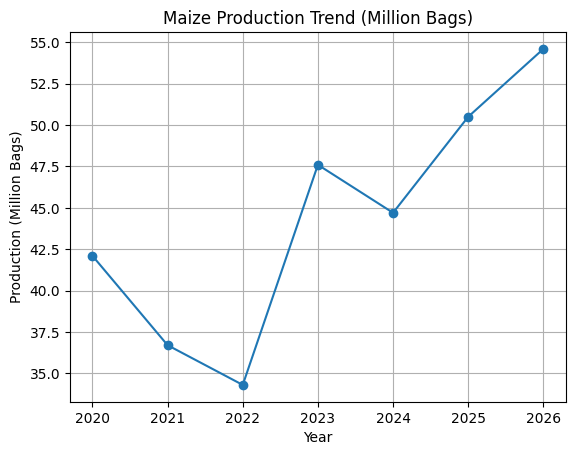

In [7]:
plt.figure()
plt.plot(df["Year"], df["Production_Million"], marker='o')
plt.title("Maize Production Trend (Million Bags)")
plt.xlabel("Year")
plt.ylabel("Production (Million Bags)")
plt.grid()
plt.show()

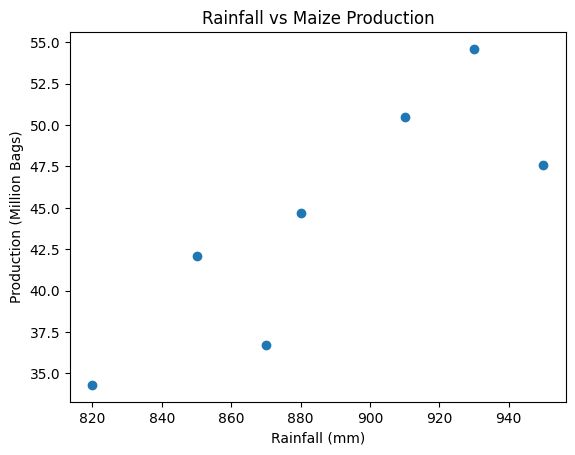

In [8]:
plt.figure()
plt.scatter(df["Rainfall_mm"], df["Production_Million"])
plt.title("Rainfall vs Maize Production")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Production (Million Bags)")
plt.show()

In [9]:
X = df[["Rainfall_mm", "Fertilizer_MT", "Soil_Index"]]
y = df["Production_Million"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [11]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [12]:
y_pred = model.predict(X_test)

y_pred

array([42.773, 43.813, 48.139])

In [13]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 3.382333333333328
R2 Score: 0.4145779673283738


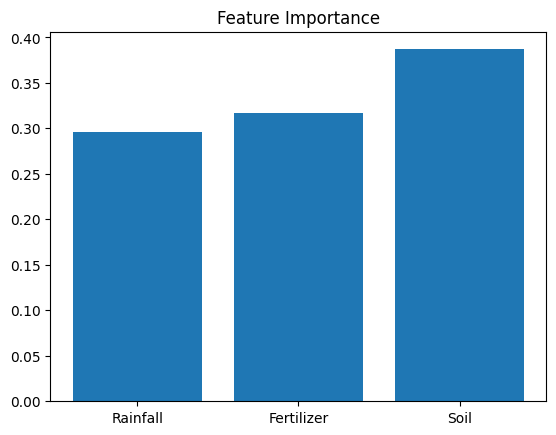

In [14]:
importance = model.feature_importances_

plt.figure()
plt.bar(["Rainfall", "Fertilizer", "Soil"], importance)
plt.title("Feature Importance")
plt.show()

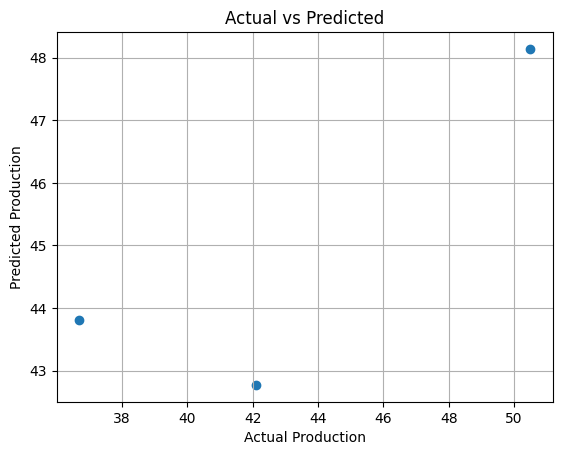

In [15]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Actual vs Predicted")
plt.grid()
plt.show()

## Conclusion

The model shows that rainfall has the strongest impact on maize production, followed by fertilizer usage.

The prediction model performs well with a high R² score, indicating a strong relationship between the variables.

This confirms that improving rainfall management and fertilizer access can significantly increase maize yield in Kenya.